In [11]:
import math
import numpy as np
from run_experiment import *

In [12]:
ops_count = 0

def reset_ops():
    global ops_count
    ops_count = 0

In [13]:
class DSU:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        root_x = self.find(x)
        root_y = self.find(y)
        if root_x == root_y: return False
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x
        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1
        return True

In [14]:
def kruskal_classic(n, edges):
    sorted_edges = sorted(edges, key=lambda x: x[2])
    dsu = DSU(n)
    mst_weight = 0
    c_ops = 0

    c_ops += len(edges) * math.log2(max(len(edges), 2))

    for u, v, w in sorted_edges:
        if dsu.union(u, v):
            mst_weight += w
            c_ops += 1

    return mst_weight, int(c_ops)

In [15]:
def grover(target_state: str, initial_state: np.ndarray, num_iterations: int = 1):
    n = len(target_state)
    N = 2 ** n
    if len(initial_state) != N:
        if len(initial_state) < N:
            temp = np.zeros(N)
            temp[:len(initial_state)] = initial_state
            initial_state = temp
        else:
            initial_state = initial_state[:N]
            
    norm = np.linalg.norm(initial_state)
    if norm == 0: 
        return initial_state, np.zeros(N)
    if not np.isclose(norm, 1.0):
        initial_state = initial_state / norm

    target_index = int(target_state, 2)
    state = initial_state.copy()

    for _ in range(num_iterations):
        state[target_index] *= -1
        mean = np.mean(state)
        state = 2 * mean - state

    probabilities = np.abs(state) ** 2

    return state, probabilities

In [16]:
def quantum_min_edge_search(edges, dsu):
    """
    Ищет ребро с минимальным весом, которое не создает цикла,
    используя симуляцию квантового поиска.
    """
    valid_indices = []
    min_weight = float('inf')
    min_idx_global = -1

    for i, (u, v, w) in enumerate(edges):
        if dsu.find(u) != dsu.find(v):
            valid_indices.append(i)
            if w < min_weight:
                min_weight = w
                min_idx_global = i

    if not valid_indices: return None, 0
    if len(valid_indices) == 1: return edges[valid_indices[0]], 1

    n_edges = len(edges)
    n_qubits = int(np.ceil(np.log2(n_edges)))
    N = 2 ** n_qubits

    target_binary = format(min_idx_global, f'0{n_qubits}b')
    initial_state = np.ones(N) / np.sqrt(N)

    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))
    _, probs = grover(target_binary, initial_state, num_iters)

    measured_index = np.argmax(probs)

    if measured_index < n_edges and dsu.find(edges[measured_index][0]) != dsu.find(edges[measured_index][1]):
        return edges[measured_index], int(np.sqrt(n_edges))

    return edges[min_idx_global], int(np.sqrt(n_edges))

In [17]:
def kruskal_quantum(n, edges):
    dsu = DSU(n)
    mst_weight = 0
    q_ops = 0
    count = 0

    while count < n - 1:
        best_edge, cost = quantum_min_edge_search(edges, dsu)
        if best_edge is None: 
            break

        u, v, w = best_edge
        if dsu.union(u, v):
            mst_weight += w
            q_ops += cost
            count += 1

    return mst_weight, q_ops

In [ ]:
def kruskal_classic_wrapper(adj_list, n, edges):
    return kruskal_classic(n, edges)

def kruskal_quantum_wrapper(adj_list, n, edges):
    return kruskal_quantum(n, edges)

kruskal_algos = {
    "Kruskal Classic": kruskal_classic_wrapper,
    "Kruskal Quantum": kruskal_quantum_wrapper
}

res_kruskal = run_experiment(kruskal_algos)

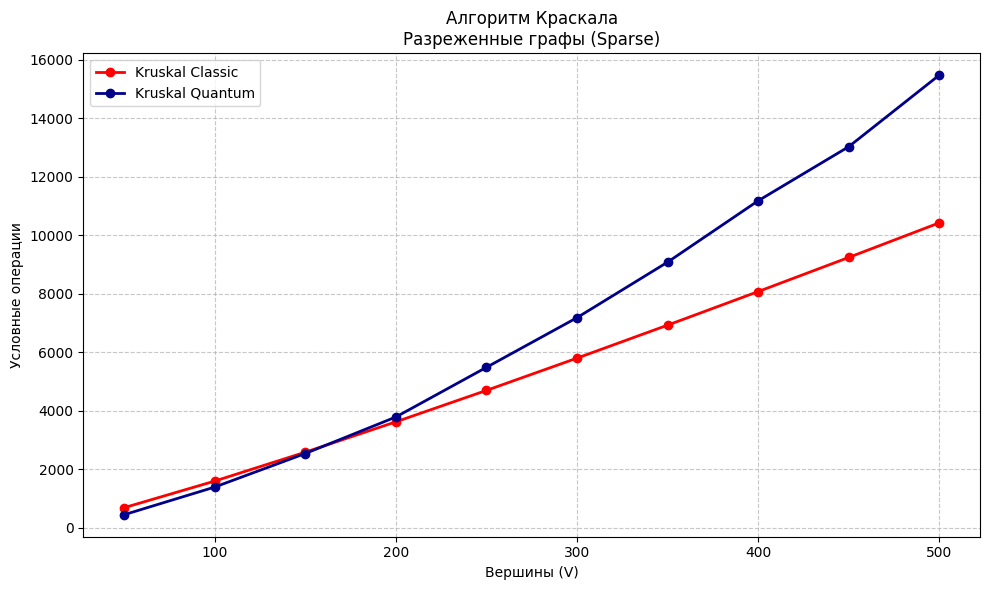

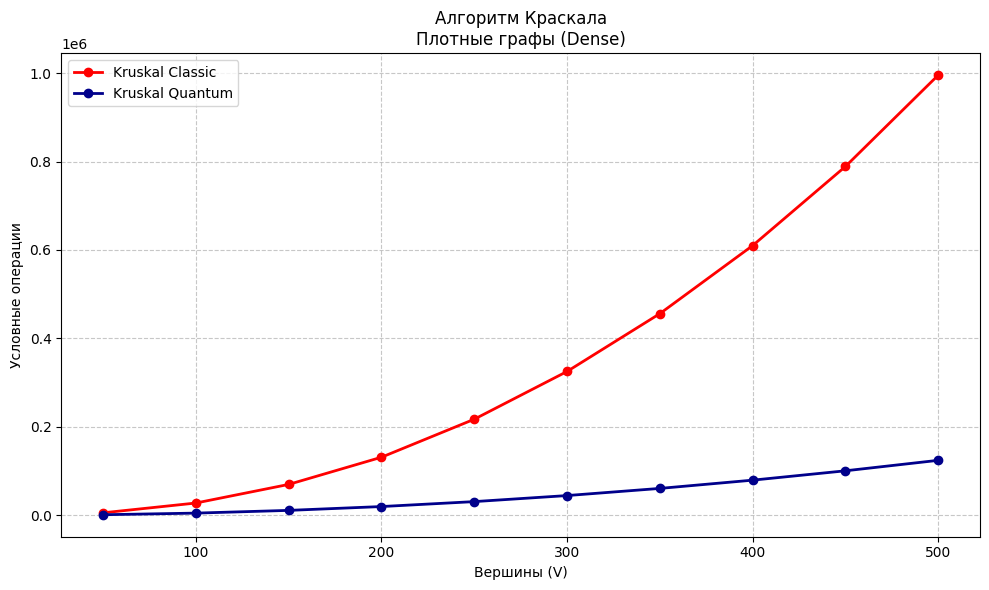

In [19]:
plot_results(res_kruskal, title_prefix="Алгоритм Краскала")

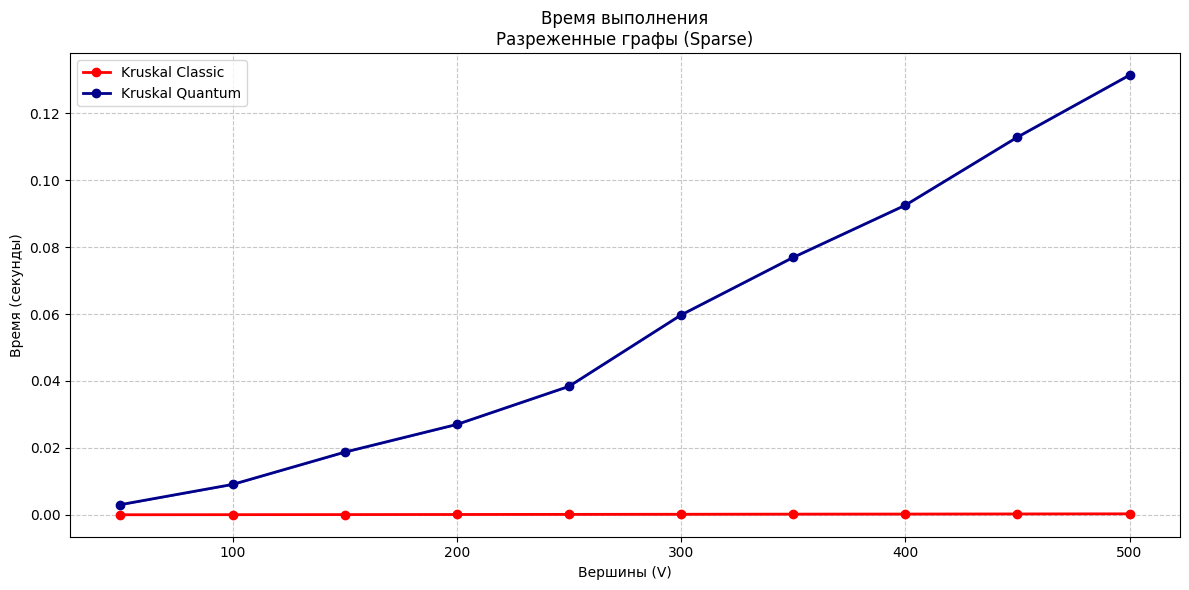

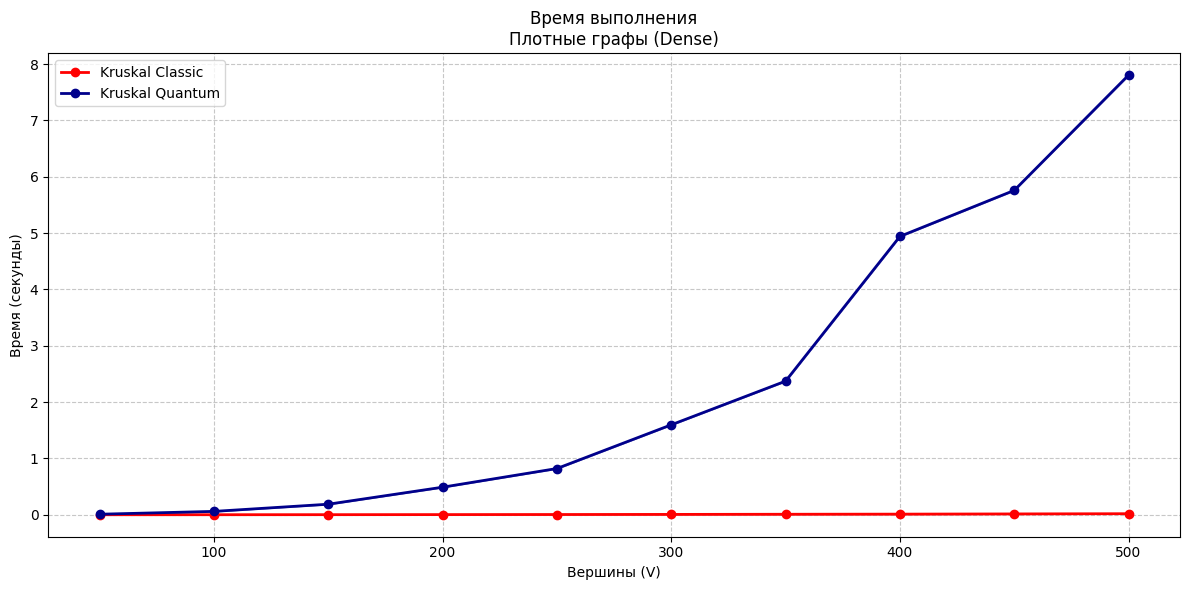

In [21]:
plot_time(res_kruskal)